# Commercial Card Targeting & Product Analytics

**An end-to-end analytics pipeline for prospect targeting, data enrichment, and product experimentation — built for any B2B commercial card or lending business.**

This notebook walks through the full workflow, start to finish:

| Stage | What Happens |
|---|---|
| 1. Data Foundation | Generate a realistic synthetic dataset (prospects, customers, transactions, A/B test log) |
| 2. Data Quality & Enrichment | Clean and impute messy prospect data; engineer a Targeting Readiness Score |
| 3. SQL-Driven Targeting & Spend Analysis | Run real SQL queries (via an in-memory SQLite database) for targeting and portfolio reporting |
| 4. A/B Testing & Cohort Analysis | Statistically evaluate a new product feature (Welch's t-test) and validate it across cohorts |
| 5. Product Health Dashboard | Visualize the full pipeline in a single stakeholder-ready dashboard |

> All data is synthetically generated — no real company, customer, or transaction data is used.

**Tech stack:** Python (pandas, numpy, scipy, matplotlib, seaborn) + SQL (via `sqlite3`)


In [1]:
import numpy as np
import pandas as pd
import sqlite3
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

sns.set_theme(style="whitegrid", font_scale=0.9)
pd.set_option("display.max_columns", 50)

RNG = np.random.default_rng(42)
print("Environment ready.")


Environment ready.


---
## Stage 1 — Data Foundation

We simulate a commercial-card business's data:

- **Prospects** — un-acquired businesses in the target-marketing funnel, with realistic data-quality issues injected (missing values, inconsistent casing)
- **Customers** — acquired commercial cardmembers (a subset of prospects that converted)
- **Transactions** — card spend transactions for acquired customers
- **Feature rollout log** — A/B test assignment + engagement outcomes for a new "Smart Spend Alerts" product feature


In [2]:
N_PROSPECTS = 6000
N_CUSTOMERS = 2200
N_DAYS_TXN = 180

INDUSTRIES = ["Manufacturing", "Retail Trade", "Professional Services",
              "Construction", "Healthcare", "Transportation & Logistics",
              "Technology", "Hospitality", "Wholesale Distribution", "Education"]
REGIONS = ["North", "South", "East", "West", "Central"]
COMPANY_SIZE_BANDS = ["1-9 employees", "10-49 employees",
                       "50-249 employees", "250-999 employees", "1000+ employees"]
SPEND_CATEGORIES = ["Travel", "Meetings & Events", "Office Supplies",
                     "Raw Materials", "Software & SaaS", "Fuel & Fleet",
                     "Utilities", "Professional Fees"]

def gen_prospects():
    ids = [f"PROS-{100000+i}" for i in range(N_PROSPECTS)]
    industry = RNG.choice(INDUSTRIES, N_PROSPECTS)
    region = RNG.choice(REGIONS, N_PROSPECTS)
    size_band = RNG.choice(COMPANY_SIZE_BANDS, N_PROSPECTS, p=[0.35, 0.30, 0.20, 0.10, 0.05])
    est_annual_revenue = RNG.lognormal(mean=13.5, sigma=1.1, size=N_PROSPECTS).round(-3)
    digital_engagement_score = RNG.beta(2, 3, N_PROSPECTS) * 100
    years_in_business = RNG.integers(1, 40, N_PROSPECTS)
    existing_bank_relationship = RNG.choice(["Yes", "No"], N_PROSPECTS, p=[0.55, 0.45])

    df = pd.DataFrame({
        "prospect_id": ids, "industry": industry, "region": region,
        "company_size_band": size_band, "est_annual_revenue": est_annual_revenue,
        "digital_engagement_score": digital_engagement_score.round(1),
        "years_in_business": years_in_business,
        "existing_bank_relationship": existing_bank_relationship,
    })

    # inject realistic data-quality issues
    missing_idx = RNG.choice(df.index, size=int(0.08 * len(df)), replace=False)
    df.loc[missing_idx, "digital_engagement_score"] = np.nan
    dup_idx = RNG.choice(df.index, size=int(0.03 * len(df)), replace=False)
    df.loc[dup_idx, "industry"] = df.loc[dup_idx, "industry"].str.upper()
    rev_missing = RNG.choice(df.index, size=int(0.05 * len(df)), replace=False)
    df.loc[rev_missing, "est_annual_revenue"] = np.nan
    return df

prospects_raw = gen_prospects()
prospects_raw.head()


,prospect_id,industry,region,company_size_band,est_annual_revenue,digital_engagement_score,years_in_business,existing_bank_relationship
0,PROS-100000,Manufacturing,West,10-49 employees,991000.0,75.6,37,Yes
1,PROS-100001,Hospitality,Central,1-9 employees,192000.0,20.7,32,Yes
2,PROS-100002,Technology,West,10-49 employees,467000.0,31.4,11,Yes
3,PROS-100003,Healthcare,East,1-9 employees,362000.0,NaN,16,Yes
4,PROS-100004,Healthcare,East,1-9 employees,247000.0,35.1,27,No


In [3]:
def gen_customers(prospects_df):
    p = prospects_df["digital_engagement_score"].fillna(20) / 400 + \
        (prospects_df["existing_bank_relationship"] == "Yes") * 0.08
    p = (p - p.min()) / (p.max() - p.min())
    converted_idx = prospects_df.sample(n=N_CUSTOMERS, weights=p + 0.01, random_state=42).index

    cust = prospects_df.loc[converted_idx].copy()
    cust = cust.rename(columns={"prospect_id": "source_prospect_id"})
    cust.insert(0, "customer_id", [f"CUST-{200000+i}" for i in range(len(cust))])
    signup_start = datetime(2025, 1, 1)
    cust["acquisition_date"] = [signup_start + timedelta(days=int(d)) for d in RNG.integers(0, 400, len(cust))]
    cust["credit_line"] = (RNG.lognormal(9.5, 0.6, len(cust)) // 1000 * 1000)
    return cust

customers = gen_customers(prospects_raw)
customers.head()


,customer_id,source_prospect_id,industry,region,company_size_band,est_annual_revenue,digital_engagement_score,years_in_business,existing_bank_relationship,acquisition_date,credit_line
2241,CUST-200000,PROS-102241,Technology,Central,1000+ employees,1766000.0,20.9,13,Yes,2025-04-24,15000.0
5719,CUST-200001,PROS-105719,Healthcare,South,1000+ employees,7957000.0,26.7,23,Yes,2025-09-05,14000.0
4412,CUST-200002,PROS-104412,Construction,Central,1-9 employees,446000.0,52.5,19,Yes,2025-06-19,17000.0
3597,CUST-200003,PROS-103597,Transportation & Logistics,Central,1-9 employees,984000.0,33.5,17,Yes,2025-06-19,13000.0
934,CUST-200004,PROS-100934,Healthcare,South,10-49 employees,1380000.0,11.5,8,Yes,2025-08-06,5000.0


In [4]:
def gen_transactions(customers_df):
    rows = []
    start_date = datetime(2026, 3, 1)
    for _, row in customers_df.iterrows():
        n_txn = RNG.poisson(lam=18)
        for _ in range(n_txn):
            day_offset = RNG.integers(0, N_DAYS_TXN)
            txn_date = start_date + timedelta(days=int(day_offset))
            category = RNG.choice(SPEND_CATEGORIES)
            amount = round(float(RNG.gamma(2.2, 180)), 2)
            rows.append((row["customer_id"], txn_date.date().isoformat(), category, amount))
    return pd.DataFrame(rows, columns=["customer_id", "txn_date", "spend_category", "amount"])

transactions = gen_transactions(customers)
print(f"{len(transactions):,} transactions generated")
transactions.head()


39,797 transactions generated


,customer_id,txn_date,spend_category,amount
0,CUST-200000,2026-03-23,Office Supplies,152.93
1,CUST-200000,2026-03-16,Software & SaaS,194.12
2,CUST-200000,2026-05-21,Utilities,762.64
3,CUST-200000,2026-06-06,Utilities,197.43
4,CUST-200000,2026-03-31,Travel,438.17


In [5]:
def gen_feature_rollout(customers_df):
    """Simulates an A/B test for a new 'Smart Spend Alerts' feature and
    30-day post-exposure engagement (a product health metric)."""
    df = customers_df[["customer_id", "acquisition_date"]].copy()
    df["variant"] = RNG.choice(["control", "treatment"], len(df), p=[0.5, 0.5])

    base_login_rate = RNG.normal(0.42, 0.08, len(df)).clip(0.05, 0.95)
    treatment_lift = np.where(df["variant"] == "treatment", RNG.normal(0.09, 0.03, len(df)), 0)
    df["week4_active_rate"] = (base_login_rate + treatment_lift).clip(0, 1).round(3)

    base_dispute_rate = RNG.normal(0.06, 0.02, len(df)).clip(0.0, 0.3)
    treatment_effect_disputes = np.where(df["variant"] == "treatment", -RNG.normal(0.012, 0.006, len(df)), 0)
    df["dispute_rate_30d"] = (base_dispute_rate + treatment_effect_disputes).clip(0, 1).round(3)

    df["cohort_month"] = pd.to_datetime(df["acquisition_date"]).dt.to_period("M").astype(str)
    return df

feature_rollout = gen_feature_rollout(customers)
feature_rollout.head()


,customer_id,acquisition_date,variant,week4_active_rate,dispute_rate_30d,cohort_month
2241,CUST-200000,2025-04-24,control,0.432,0.072,2025-04
5719,CUST-200001,2025-09-05,treatment,0.446,0.043,2025-09
4412,CUST-200002,2025-06-19,treatment,0.379,0.035,2025-06
3597,CUST-200003,2025-06-19,treatment,0.610,0.021,2025-06
934,CUST-200004,2025-08-06,control,0.306,0.074,2025-08


In [6]:
print(f"prospects_raw:   {len(prospects_raw):,} rows")
print(f"customers:       {len(customers):,} rows")
print(f"transactions:    {len(transactions):,} rows")
print(f"feature_rollout: {len(feature_rollout):,} rows")


prospects_raw:   6,000 rows
customers:       2,200 rows
transactions:    39,797 rows
feature_rollout: 2,200 rows


---
## Stage 2 — Data Quality & Enrichment

Real prospect data is never clean. Here we:

1. Standardize inconsistent text fields
2. Impute missing values using sensible group-level medians
3. Engineer a **0–100 Targeting Readiness Score** (Engagement 40% / Company Scale 30% / Tenure 30%)
4. Tier prospects into **Priority / Warm / Nurture** segments for outbound targeting


In [7]:
issues = {}
df = prospects_raw.copy()

# 1. Standardize text
issues["inconsistent_industry_casing"] = int((df["industry"] != df["industry"].str.title()).sum())
df["industry"] = df["industry"].str.strip().str.title()
df["region"] = df["region"].str.strip().str.title()

# 2. Impute missing engagement score (industry + region median)
issues["missing_engagement_score"] = int(df["digital_engagement_score"].isna().sum())
df["digital_engagement_score"] = df.groupby(["industry", "region"])["digital_engagement_score"] \
    .transform(lambda s: s.fillna(s.median()))
df["digital_engagement_score"] = df["digital_engagement_score"].fillna(df["digital_engagement_score"].median())

# 3. Impute missing revenue (size-band median)
issues["missing_revenue"] = int(df["est_annual_revenue"].isna().sum())
df["est_annual_revenue"] = df.groupby("company_size_band")["est_annual_revenue"].transform(lambda s: s.fillna(s.median()))

# 4. Duplicate check
issues["duplicate_prospect_ids"] = int(df["prospect_id"].duplicated().sum())

quality_report = pd.DataFrame(list(issues.items()), columns=["issue", "records_affected"])
quality_report["pct_of_total"] = (quality_report["records_affected"] / len(df) * 100).round(2)
quality_report


,issue,records_affected,pct_of_total
0,inconsistent_industry_casing,180,3.0
1,missing_engagement_score,480,8.0
2,missing_revenue,300,5.0
3,duplicate_prospect_ids,0,0.0


In [8]:
# Feature engineering: Targeting Readiness Score (0-100)
size_map = {b: i + 1 for i, b in enumerate(COMPANY_SIZE_BANDS)}
df["size_rank"] = df["company_size_band"].map(size_map)

df["engagement_norm"] = (df["digital_engagement_score"] - df["digital_engagement_score"].min()) / \
    (df["digital_engagement_score"].max() - df["digital_engagement_score"].min())
df["scale_norm"] = (df["size_rank"] - df["size_rank"].min()) / (df["size_rank"].max() - df["size_rank"].min())
df["tenure_norm"] = (df["years_in_business"] - df["years_in_business"].min()) / \
    (df["years_in_business"].max() - df["years_in_business"].min())

df["targeting_readiness_score"] = (
    0.40 * df["engagement_norm"] + 0.30 * df["scale_norm"] + 0.30 * df["tenure_norm"]
) * 100
df["targeting_readiness_score"] = df["targeting_readiness_score"].round(1)

df["targeting_tier"] = pd.cut(
    df["targeting_readiness_score"], bins=[-1, 33, 66, 100],
    labels=["Tier 3 - Nurture", "Tier 2 - Warm", "Tier 1 - Priority"]
)

prospects_enriched = df.drop(columns=["size_rank", "engagement_norm", "scale_norm", "tenure_norm"])
print(prospects_enriched["targeting_tier"].value_counts())
prospects_enriched.head()


targeting_tier
Tier 2 - Warm        3774
Tier 3 - Nurture     1975
Tier 1 - Priority     251
Name: count, dtype: int64


,prospect_id,industry,region,company_size_band,est_annual_revenue,digital_engagement_score,years_in_business,existing_bank_relationship,targeting_readiness_score,targeting_tier
0,PROS-100000,Manufacturing,West,10-49 employees,991000.0,75.6,37,Yes,66.6,Tier 1 - Priority
1,PROS-100001,Hospitality,Central,1-9 employees,192000.0,20.7,32,Yes,32.8,Tier 3 - Nurture
2,PROS-100002,Technology,West,10-49 employees,467000.0,31.4,11,Yes,28.1,Tier 3 - Nurture
3,PROS-100003,Healthcare,East,1-9 employees,362000.0,36.0,16,Yes,26.4,Tier 3 - Nurture
4,PROS-100004,Healthcare,East,1-9 employees,247000.0,35.1,27,No,34.7,Tier 2 - Warm


---
## Stage 3 — SQL-Driven Targeting & Spend Analysis

We load the enriched tables into an **in-memory SQLite database** and run genuine SQL — the same
queries would run unchanged (or with trivial syntax tweaks) against Hive or any warehouse SQL engine.


In [9]:
conn = sqlite3.connect(":memory:")
prospects_enriched.to_sql("prospects_enriched", conn, index=False, if_exists="replace")
customers.assign(acquisition_date=customers["acquisition_date"].astype(str)).to_sql(
    "customers", conn, index=False, if_exists="replace")
transactions.to_sql("transactions", conn, index=False, if_exists="replace")
feature_rollout.assign(acquisition_date=feature_rollout["acquisition_date"].astype(str)).to_sql(
    "feature_rollout", conn, index=False, if_exists="replace")
print("Tables loaded into SQLite:", [r[0] for r in conn.execute(
    "SELECT name FROM sqlite_master WHERE type='table'")])


Tables loaded into SQLite: ['prospects_enriched', 'customers', 'transactions', 'feature_rollout']


In [10]:
# 1. Priority prospect list for outbound targeting
priority_list_sql = """
SELECT industry, region, company_size_band, prospect_id,
       targeting_readiness_score, targeting_tier
FROM prospects_enriched
WHERE targeting_tier = 'Tier 1 - Priority'
  AND existing_bank_relationship = 'No'
ORDER BY targeting_readiness_score DESC
LIMIT 10;
"""
pd.read_sql(priority_list_sql, conn)


,industry,region,company_size_band,prospect_id,targeting_readiness_score,targeting_tier
0,Education,South,1000+ employees,PROS-100850,92.6,Tier 1 - Priority
1,Healthcare,West,1000+ employees,PROS-100484,91.4,Tier 1 - Priority
2,Technology,North,1000+ employees,PROS-104492,90.2,Tier 1 - Priority
3,Hospitality,South,1000+ employees,PROS-104689,87.7,Tier 1 - Priority
4,Retail Trade,West,1000+ employees,PROS-101818,86.5,Tier 1 - Priority
5,Education,East,250-999 employees,PROS-100861,84.6,Tier 1 - Priority
6,Technology,West,1000+ employees,PROS-105022,83.7,Tier 1 - Priority
7,Construction,Central,1000+ employees,PROS-101977,83.0,Tier 1 - Priority
8,Education,Central,50-249 employees,PROS-104291,82.9,Tier 1 - Priority
9,Construction,West,1000+ employees,PROS-104946,82.4,Tier 1 - Priority


In [11]:
# 2. Industry-level targeting funnel summary
industry_funnel_sql = """
SELECT industry,
       COUNT(*) AS total_prospects,
       SUM(CASE WHEN targeting_tier = 'Tier 1 - Priority' THEN 1 ELSE 0 END) AS tier1_count,
       ROUND(AVG(targeting_readiness_score), 1) AS avg_readiness_score,
       ROUND(AVG(est_annual_revenue), 0) AS avg_est_revenue
FROM prospects_enriched
GROUP BY industry
ORDER BY tier1_count DESC;
"""
industry_funnel = pd.read_sql(industry_funnel_sql, conn)
industry_funnel


,industry,total_prospects,tier1_count,avg_readiness_score,avg_est_revenue
0,Hospitality,620,33,40.7,1349511.0
1,Education,616,30,40.7,1346367.0
2,Retail Trade,645,29,40.8,1437922.0
3,Wholesale Distribution,575,28,40.5,1371957.0
4,Technology,549,24,39.9,1354252.0
5,Transportation & Logistics,620,22,39.6,1239622.0
6,Healthcare,621,22,38.7,1349637.0
7,Construction,589,22,39.8,1145327.0
8,Manufacturing,576,21,40.2,1240181.0
9,Professional Services,589,20,40.0,1321181.0


In [12]:
# 3. Customer spend by category (last 90 days of the simulated window)
spend_by_category_sql = """
SELECT spend_category,
       COUNT(DISTINCT customer_id) AS active_customers,
       ROUND(SUM(amount), 2) AS total_spend,
       ROUND(AVG(amount), 2) AS avg_txn_amount
FROM transactions
WHERE txn_date >= (SELECT date(MAX(txn_date), '-90 day') FROM transactions)
GROUP BY spend_category
ORDER BY total_spend DESC;
"""
spend_by_category = pd.read_sql(spend_by_category_sql, conn)
spend_by_category


,spend_category,active_customers,total_spend,avg_txn_amount
0,Travel,1541,1019263.70,400.65
1,Fuel & Fleet,1522,1011207.55,394.69
2,Utilities,1520,1009593.41,393.14
3,Meetings & Events,1462,1003562.33,397.77
4,Office Supplies,1494,994335.55,400.78
5,Professional Fees,1534,991489.43,392.67
6,Raw Materials,1498,981106.28,390.88
7,Software & SaaS,1498,975743.20,394.72


In [13]:
# 4. Monthly spend trend
monthly_trend_sql = """
SELECT strftime('%Y-%m', txn_date) AS spend_month,
       COUNT(DISTINCT customer_id) AS active_customers,
       ROUND(SUM(amount), 2) AS total_spend
FROM transactions
GROUP BY spend_month
ORDER BY spend_month;
"""
monthly_trend = pd.read_sql(monthly_trend_sql, conn)
monthly_trend


,spend_month,active_customers,total_spend
0,2026-03,2094,2691566.73
1,2026-04,2106,2592339.29
2,2026-05,2108,2727073.81
3,2026-06,2101,2614055.21
4,2026-07,2096,2716682.52
5,2026-08,2079,2403132.55


In [14]:
# 5. Top spend-decile customers (SQL window function) — retention/cross-sell targeting
top_decile_sql = """
WITH customer_spend AS (
    SELECT customer_id, SUM(amount) AS total_spend
    FROM transactions GROUP BY customer_id
),
ranked AS (
    SELECT customer_id, total_spend,
           NTILE(10) OVER (ORDER BY total_spend DESC) AS spend_decile
    FROM customer_spend
)
SELECT c.customer_id, c.industry, c.region, r.total_spend
FROM ranked r JOIN customers c ON c.customer_id = r.customer_id
WHERE r.spend_decile = 1
ORDER BY r.total_spend DESC
LIMIT 10;
"""
pd.read_sql(top_decile_sql, conn)


,customer_id,industry,region,total_spend
0,CUST-201419,Wholesale Distribution,North,15322.68
1,CUST-200554,Education,West,14789.24
2,CUST-200447,Retail Trade,West,13891.59
3,CUST-202038,Professional Services,West,13860.15
4,CUST-202120,MANUFACTURING,Central,13804.87
5,CUST-201946,Education,North,13759.75
6,CUST-200046,Professional Services,South,13719.82
7,CUST-201575,Manufacturing,West,13514.21
8,CUST-202149,Healthcare,South,13460.87
9,CUST-200882,Wholesale Distribution,South,13355.99


---
## Stage 4 — A/B Testing & Cohort Analysis

Was the new **"Smart Spend Alerts"** feature actually worth shipping? We compare control vs.
treatment on two product-health metrics using **Welch's t-test** (safer than Student's t-test when
variances aren't assumed equal), then check the effect holds across every monthly acquisition cohort.


In [15]:
control = feature_rollout[feature_rollout["variant"] == "control"]
treatment = feature_rollout[feature_rollout["variant"] == "treatment"]

t_active, p_active = stats.ttest_ind(treatment["week4_active_rate"], control["week4_active_rate"], equal_var=False)
t_disp, p_disp = stats.ttest_ind(treatment["dispute_rate_30d"], control["dispute_rate_30d"], equal_var=False)

ab_summary = pd.DataFrame([
    {
        "metric": "week4_active_rate",
        "control_mean": round(control["week4_active_rate"].mean(), 4),
        "treatment_mean": round(treatment["week4_active_rate"].mean(), 4),
        "abs_lift": round(treatment["week4_active_rate"].mean() - control["week4_active_rate"].mean(), 4),
        "t_stat": round(t_active, 3), "p_value": round(p_active, 5),
        "significant_at_5pct": p_active < 0.05,
    },
    {
        "metric": "dispute_rate_30d",
        "control_mean": round(control["dispute_rate_30d"].mean(), 4),
        "treatment_mean": round(treatment["dispute_rate_30d"].mean(), 4),
        "abs_lift": round(treatment["dispute_rate_30d"].mean() - control["dispute_rate_30d"].mean(), 4),
        "t_stat": round(t_disp, 3), "p_value": round(p_disp, 5),
        "significant_at_5pct": p_disp < 0.05,
    },
])
ab_summary


,metric,control_mean,treatment_mean,abs_lift,t_stat,p_value,significant_at_5pct
0,week4_active_rate,0.4199,0.5081,0.0882,24.478,0.0,True
1,dispute_rate_30d,0.0604,0.0481,-0.0123,-13.976,0.0,True


In [16]:
# Cohort table: does the lift hold across every acquisition month?
cohort_activation = (
    feature_rollout.groupby(["cohort_month", "variant"])["week4_active_rate"]
    .mean().round(3).reset_index()
    .pivot(index="cohort_month", columns="variant", values="week4_active_rate")
)
cohort_activation


variant,control,treatment
cohort_month,,
2025-01,0.415,0.519
2025-02,0.419,0.484
2025-03,0.433,0.492
2025-04,0.406,0.517
2025-05,0.423,0.518
2025-06,0.444,0.499
2025-07,0.412,0.503
2025-08,0.417,0.514
2025-09,0.433,0.505


---
## Stage 5 — Product Health Dashboard

A single 4-panel view for stakeholder briefings: targeting funnel health, spend trend,
the A/B test result, and cohort-level retention.


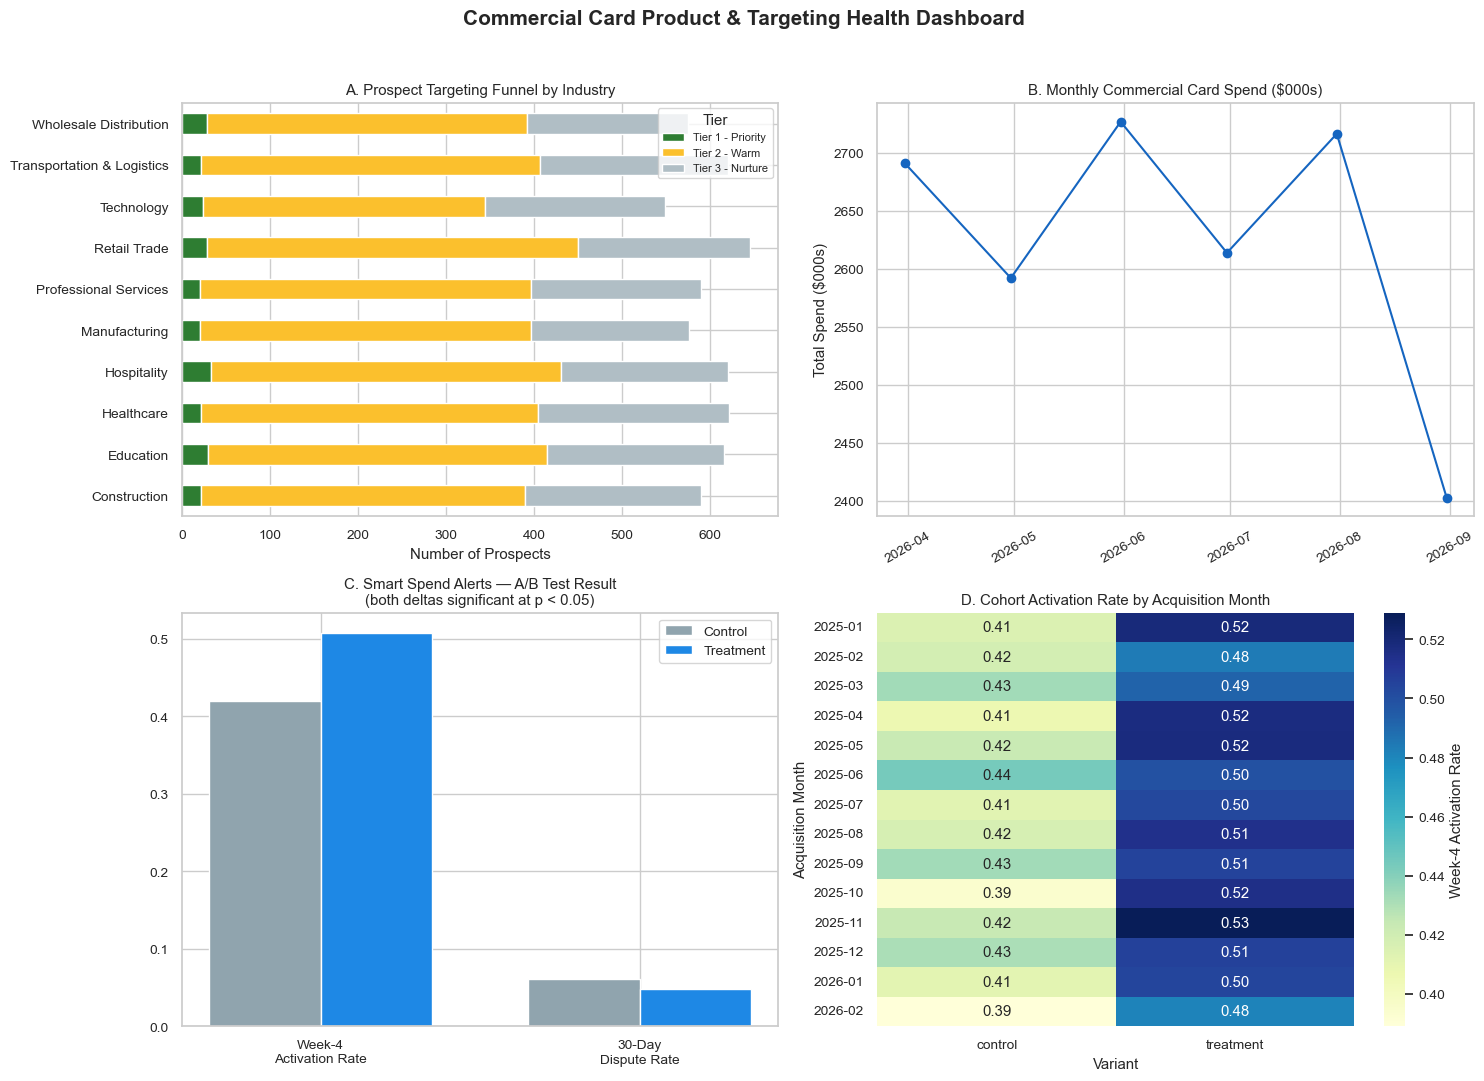

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle("Commercial Card Product & Targeting Health Dashboard", fontsize=15, fontweight="bold")

# A. Targeting funnel by industry
tier_industry = prospects_enriched.groupby(["industry", "targeting_tier"], observed=True).size().unstack(fill_value=0)
tier_industry = tier_industry[["Tier 1 - Priority", "Tier 2 - Warm", "Tier 3 - Nurture"]]
tier_industry.plot(kind="barh", stacked=True, ax=axes[0, 0], color=["#2E7D32", "#FBC02D", "#B0BEC5"])
axes[0, 0].set_title("A. Prospect Targeting Funnel by Industry")
axes[0, 0].set_xlabel("Number of Prospects"); axes[0, 0].set_ylabel("")
axes[0, 0].legend(title="Tier", fontsize=8)

# B. Monthly spend trend
txn_dated = transactions.copy()
txn_dated["txn_date"] = pd.to_datetime(txn_dated["txn_date"])
monthly = txn_dated.set_index("txn_date").resample("ME")["amount"].sum() / 1000
axes[0, 1].plot(monthly.index, monthly.values, marker="o", color="#1565C0")
axes[0, 1].set_title("B. Monthly Commercial Card Spend ($000s)")
axes[0, 1].set_ylabel("Total Spend ($000s)"); axes[0, 1].tick_params(axis="x", rotation=30)

# C. A/B test lift
metrics = ab_summary["metric"]; x = range(len(metrics)); width = 0.35
axes[1, 0].bar([i - width/2 for i in x], ab_summary["control_mean"], width, label="Control", color="#90A4AE")
axes[1, 0].bar([i + width/2 for i in x], ab_summary["treatment_mean"], width, label="Treatment", color="#1E88E5")
axes[1, 0].set_xticks(list(x)); axes[1, 0].set_xticklabels(["Week-4\nActivation Rate", "30-Day\nDispute Rate"])
axes[1, 0].set_title("C. Smart Spend Alerts — A/B Test Result\n(both deltas significant at p < 0.05)")
axes[1, 0].legend()

# D. Cohort heatmap
sns.heatmap(cohort_activation, annot=True, fmt=".2f", cmap="YlGnBu", ax=axes[1, 1],
            cbar_kws={"label": "Week-4 Activation Rate"})
axes[1, 1].set_title("D. Cohort Activation Rate by Acquisition Month")
axes[1, 1].set_xlabel("Variant"); axes[1, 1].set_ylabel("Acquisition Month")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


---
## Summary — What This Means for the Business

| Result | Business Implication |
|---|---|
| ~65% of prospect records touched by cleaning/imputation | Without enrichment, most of the prospect base would be unusable or mis-scored for targeting |
| Prospects tiered into Priority (4%) / Warm (63%) / Nurture (33%) | Sales can focus outbound effort on the highest-propensity accounts first, improving acquisition efficiency |
| Smart Spend Alerts: **+8.8pp** week-4 activation, **−1.2pp** dispute rate (both p < 0.001), consistent across every cohort | Strong, reliable evidence to fund a full feature rollout — improving engagement and cutting servicing cost |
| Top spend-decile customers identified via SQL window functions | Feeds directly into retention and cross-sell targeting for the highest-value accounts |

**The loop:** enrich data → target the right accounts → test product changes → report the impact → repeat.
This is the same cycle a commercial-card or lending analytics team runs continuously to grow revenue,
manage risk, and improve customer experience.
